# ❤️ Heart Disease Prediction — Advanced Professional ML Portfolio

**Project type:** End-to-end supervised machine learning classification  
**Dataset:** `Heart_Disease_Prediction (3).csv`  
**Target:** `Heart Disease`  
**Portfolio focus:** robust preprocessing, leakage prevention, stratified validation, model comparison, hyperparameter optimization, probability calibration, threshold optimization, explainability, error analysis, and reproducible model packaging.

> **Medical disclaimer:** This is an educational ML portfolio project, not a clinical diagnostic system. Model performance on this small dataset must not be interpreted as evidence of clinical safety or real-world deployment readiness.


## 1. Executive Project Objective

### Problem
Predict whether a patient record is associated with heart disease (`Heart Disease = 1`) from the clinical variables supplied in the dataset.

### ML task
Binary classification.

### Primary evaluation priorities
Because this is a health-related classification problem, accuracy alone is insufficient. We will emphasize:

- **ROC-AUC** — ranking/discrimination
- **PR-AUC** — useful when positive cases are less frequent
- **Recall / Sensitivity** — ability to identify positive cases
- **Precision** — reliability of positive predictions
- **F1-score** — balance between precision and recall
- **Specificity** — ability to identify negative cases
- **Brier score / calibration** — quality of predicted probabilities

### Portfolio goals
1. Build a leakage-safe baseline.
2. Compare several model families.
3. Tune the strongest candidates using stratified cross-validation.
4. Select a final model using validation evidence rather than a single lucky split.
5. Calibrate probabilities where useful.
6. Optimize the classification threshold separately from model fitting.
7. Analyze errors and feature influence.
8. Save a reproducible inference pipeline.


## 2. Dataset Audit

The supplied file contains **270 rows and 15 columns**.

Important observation from the actual dataset:

- `Heart Disease` is the binary target.
- `ID` is almost entirely missing and behaves like an identifier, so it will be excluded rather than imputed.
- `Sex` is textual (`Male` / `Female`).
- Several integer-valued variables are actually **coded clinical categories**, not continuous measurements. We will preserve that distinction in preprocessing.
- The dataset contains no duplicate rows and the target has both classes.

We will verify these facts programmatically before modeling.


In [1]:
# Colab / local setup
import sys, subprocess, importlib.util

required = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "sklearn": "scikit-learn",
    "joblib": "joblib",
}

missing = [pip_name for module, pip_name in required.items()
           if importlib.util.find_spec(module) is None]

if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + missing)

# XGBoost is optional but recommended for the portfolio benchmark.
if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "xgboost"])

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
    cross_validate, RandomizedSearchCV, cross_val_predict
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay, brier_score_loss, make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, ExtraTreesClassifier,
    GradientBoostingClassifier, HistGradientBoostingClassifier,
    VotingClassifier, StackingClassifier
)
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.inspection import permutation_importance
from sklearn.base import clone

from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Environment ready.")


Environment ready.


In [2]:
# Load the dataset
from pathlib import Path

DATA_PATH = Path("/content/Heart_Disease_Prediction (3).csv")

# If the notebook is running locally and the file is elsewhere, change DATA_PATH.
# In Google Colab, uncomment the next block if the file is not already present.

if not DATA_PATH.exists():
    try:
        from google.colab import files
        uploaded = files.upload()
        uploaded_name = next(iter(uploaded))
        DATA_PATH = Path("/content") / uploaded_name
    except Exception as e:
        raise FileNotFoundError(
            "Dataset not found. Upload Heart_Disease_Prediction (3).csv "
            "or update DATA_PATH."
        ) from e

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (270, 15)


,ID,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,1.0,70,Male,4,130,322,0,2,109,0,2.4,2,3,3,1
1,2.0,67,Female,3,115,564,0,2,160,0,1.6,2,0,7,0
2,3.0,57,Male,2,124,261,0,0,141,0,0.3,1,0,7,1
3,NaN,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,0
4,NaN,74,Female,2,120,269,0,2,121,1,0.2,1,1,3,0


In [3]:
# Core audit
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False).to_frame("missing"))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget distribution:")
display(df["Heart Disease"].value_counts(dropna=False).to_frame("count"))

print("\nTarget proportion:")
display(df["Heart Disease"].value_counts(normalize=True).to_frame("proportion"))

print("\nUnique values:")
display(df.nunique().sort_values().to_frame("n_unique"))


Shape: (270, 15)

Data types:


,dtype
ID,float64
Age,int64
Sex,object
Chest pain type,int64
BP,int64
Cholesterol,int64
FBS over 120,int64
EKG results,int64
Max HR,int64
Exercise angina,int64



Missing values:


,missing
ID,267
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0



Duplicate rows: 0

Target distribution:


,count
Heart Disease,
0,150
1,120



Target proportion:


,proportion
Heart Disease,
0,0.555556
1,0.444444



Unique values:


,n_unique
Sex,2
FBS over 120,2
Heart Disease,2
Exercise angina,2
Slope of ST,3
Thallium,3
EKG results,3
ID,3
Number of vessels fluro,4
Chest pain type,4


## 3. Data Quality Decisions

### Identifier handling
`ID` will be removed. It contains only three observed values and is therefore not a meaningful predictive feature.

### Missingness
The only substantial missingness is in `ID`. Since `ID` is excluded, the modeling features are complete in this supplied dataset.

### Categorical treatment
The following variables represent discrete/coded categories and will be treated as categorical:

- `Sex`
- `Chest pain type`
- `FBS over 120`
- `EKG results`
- `Exercise angina`
- `Slope of ST`
- `Number of vessels fluro`
- `Thallium`

Continuous/numeric measurements:

- `Age`
- `BP`
- `Cholesterol`
- `Max HR`
- `ST depression`

This prevents the model from automatically assuming that category code `4` is mathematically twice as meaningful as code `2`.


In [4]:
# Define target and modeling features
TARGET = "Heart Disease"
ID_COLUMNS = ["ID"]

X = df.drop(columns=[TARGET] + ID_COLUMNS)
y = df[TARGET].astype(int)

categorical_features = [
    "Sex",
    "Chest pain type",
    "FBS over 120",
    "EKG results",
    "Exercise angina",
    "Slope of ST",
    "Number of vessels fluro",
    "Thallium",
]

numeric_features = [
    "Age",
    "BP",
    "Cholesterol",
    "Max HR",
    "ST depression",
]

assert set(categorical_features + numeric_features) == set(X.columns)

print("X shape:", X.shape)
print("Categorical:", categorical_features)
print("Numeric:", numeric_features)


X shape: (270, 13)
Categorical: ['Sex', 'Chest pain type', 'FBS over 120', 'EKG results', 'Exercise angina', 'Slope of ST', 'Number of vessels fluro', 'Thallium']
Numeric: ['Age', 'BP', 'Cholesterol', 'Max HR', 'ST depression']


## 4. Exploratory Data Analysis

The EDA is intentionally descriptive rather than model-driven. The test set will remain untouched until final evaluation.

We will inspect:

- target balance
- numerical distributions
- categorical distributions
- relationships with the target
- correlations among continuous variables
- potential outliers

EDA observations should be reported from the generated plots rather than assumed in advance.


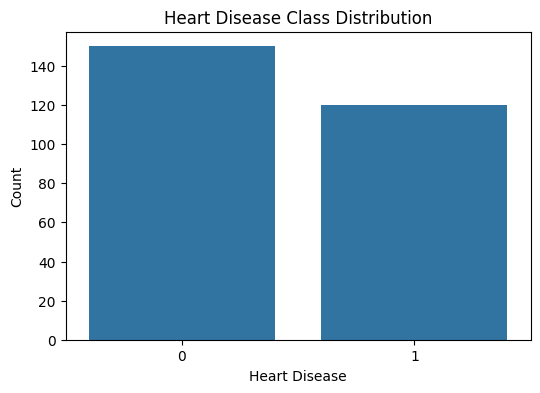

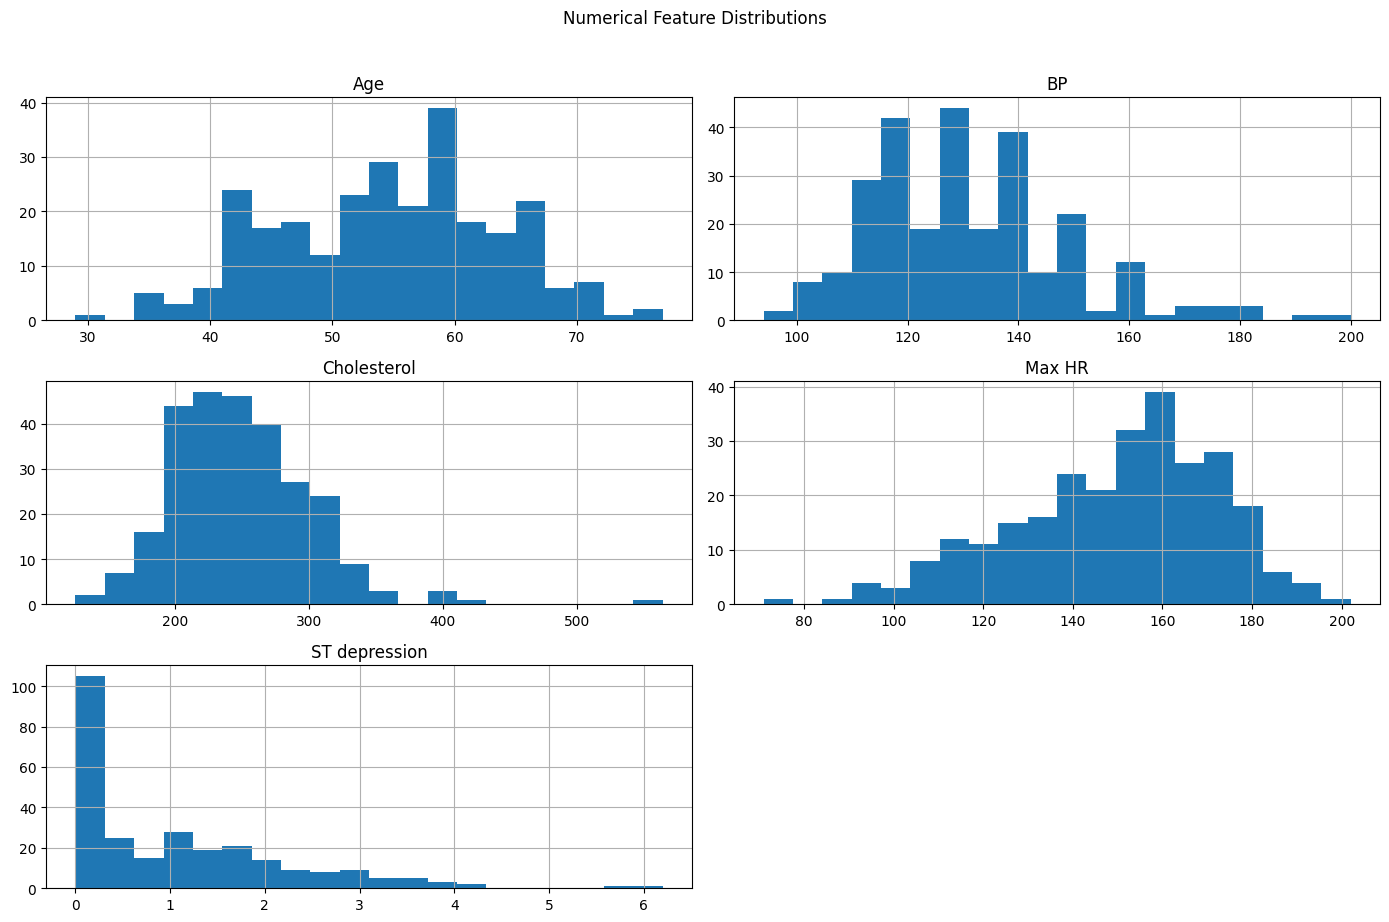

In [5]:
# Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=TARGET)
plt.title("Heart Disease Class Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

# Numerical distributions
df[numeric_features].hist(figsize=(14, 9), bins=20)
plt.suptitle("Numerical Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


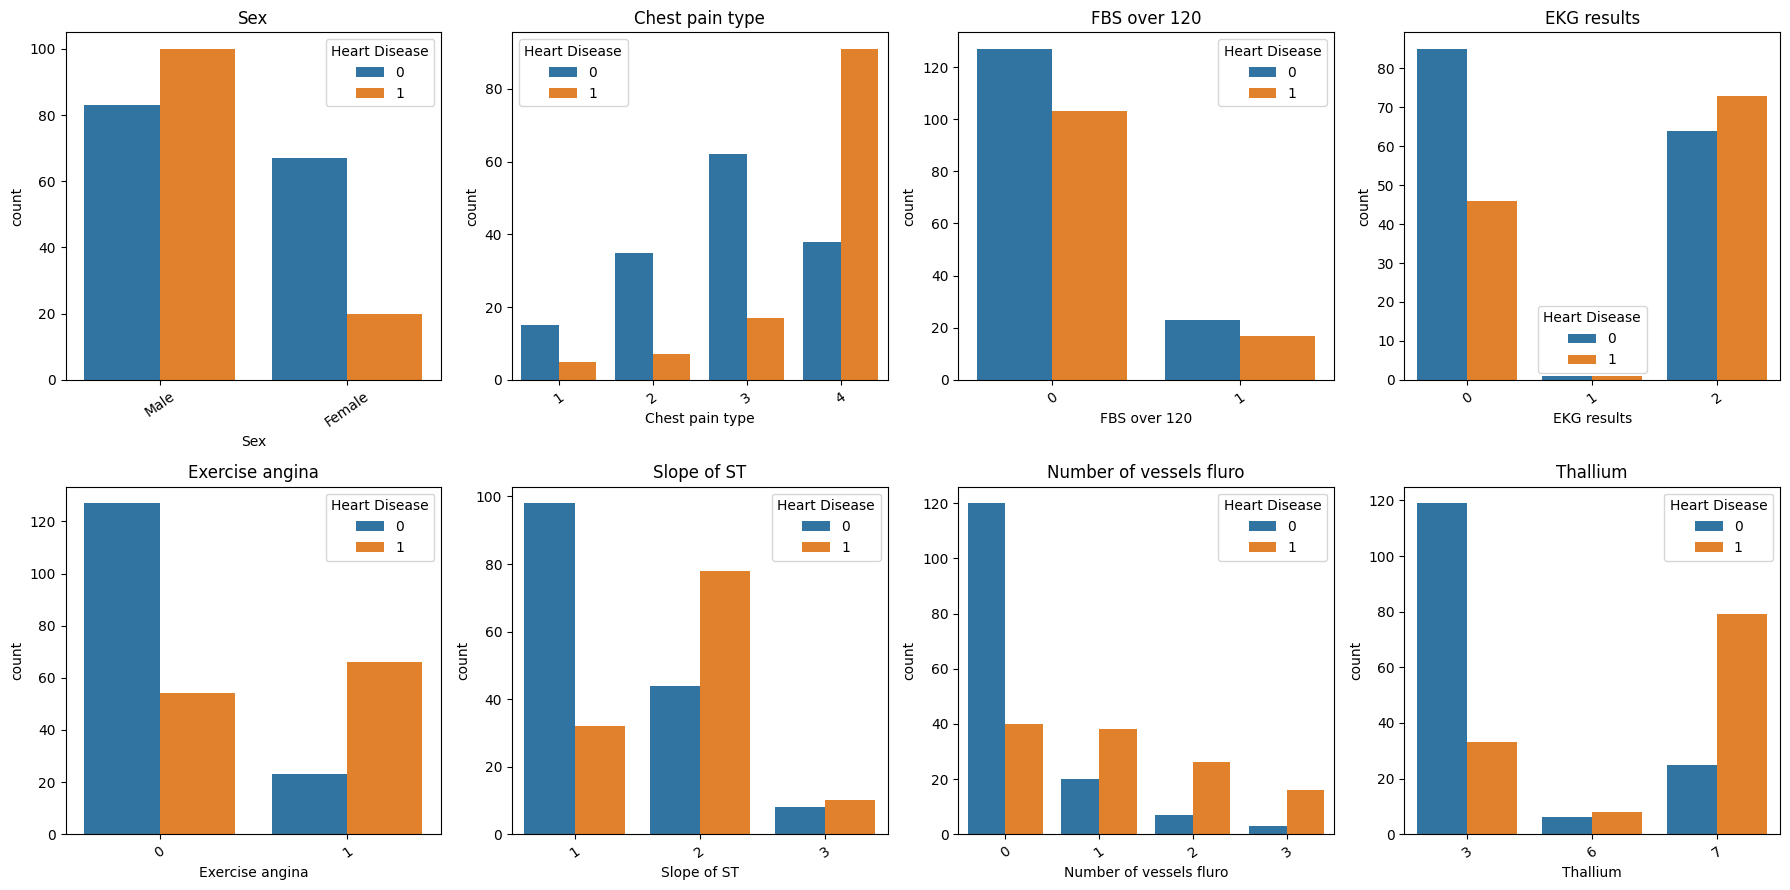

In [6]:
# Categorical distributions
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
for ax, col in zip(axes.ravel(), categorical_features):
    sns.countplot(data=df, x=col, hue=TARGET, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


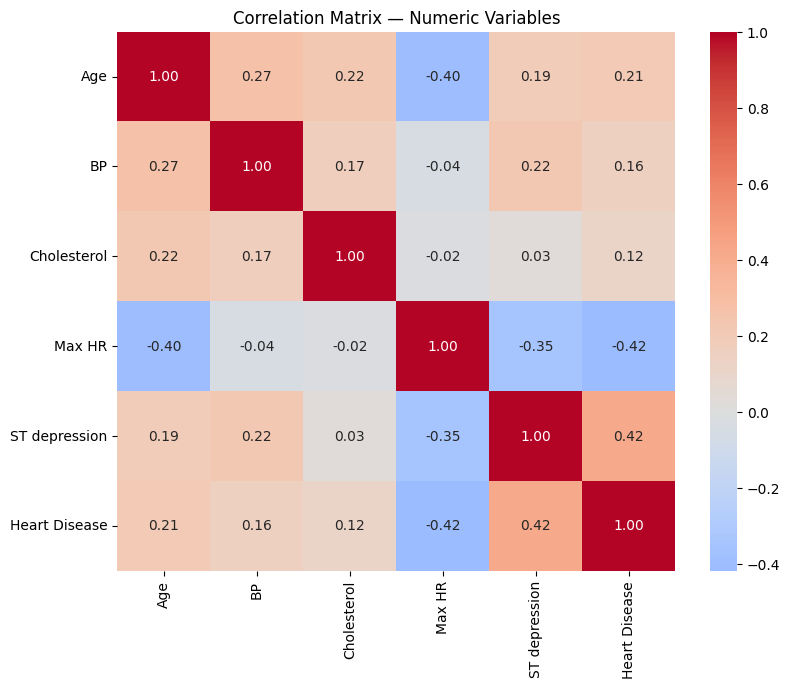

In [7]:
# Continuous-feature correlation matrix
plt.figure(figsize=(9, 7))
sns.heatmap(df[numeric_features + [TARGET]].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Matrix — Numeric Variables")
plt.show()


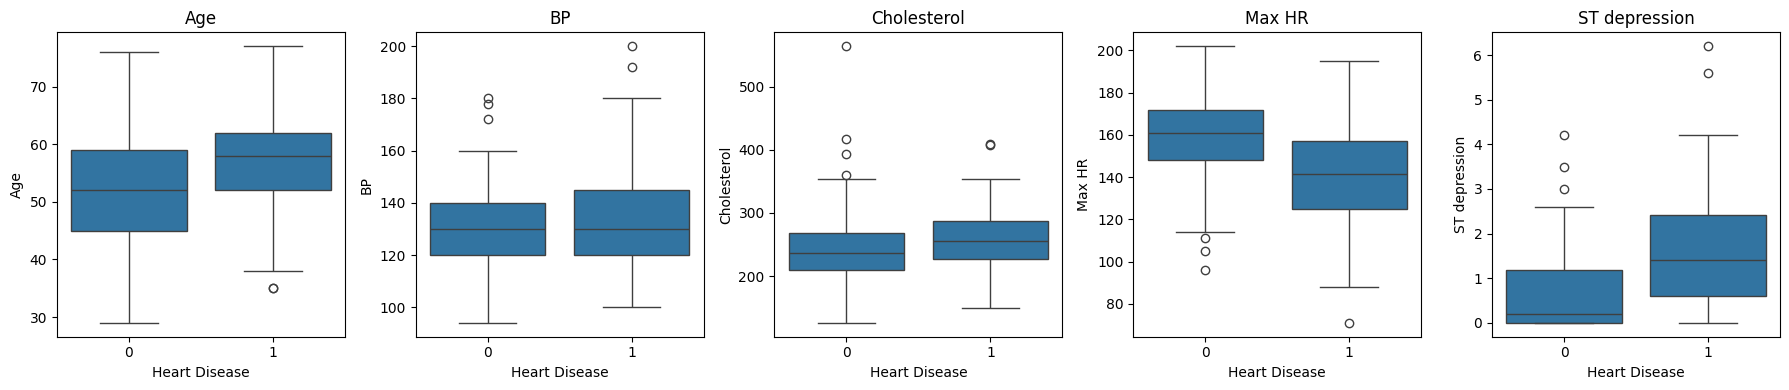

In [8]:
# Numeric features by target
fig, axes = plt.subplots(1, len(numeric_features), figsize=(18, 4))
for ax, col in zip(axes, numeric_features):
    sns.boxplot(data=df, x=TARGET, y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


## 5. Leakage-Safe Train/Test Split

A fixed stratified holdout will be reserved for final evaluation.

**Important:** all imputation, scaling, one-hot encoding, model fitting, and tuning happen inside scikit-learn pipelines. This prevents preprocessing information from leaking from validation folds into training folds.

The holdout test set is not used to choose hyperparameters or the decision threshold.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training:", X_train.shape, y_train.value_counts().to_dict())
print("Holdout:", X_test.shape, y_test.value_counts().to_dict())


Training: (216, 13) {0: 120, 1: 96}
Holdout: (54, 13) {0: 30, 1: 24}


## 6. Reusable Preprocessing Pipeline

### Numeric branch
- median imputation
- standardization

### Categorical branch
- most-frequent imputation
- one-hot encoding with `handle_unknown="ignore"`

All transformations are fitted only on the training data through the pipeline.


In [10]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

print("Preprocessor created.")


Preprocessor created.


## 7. Baseline Model

The baseline is logistic regression.

Why?

- interpretable
- strong classical baseline for binary classification
- produces probabilities
- works naturally with standardized numeric features and one-hot categorical features
- gives a reference point for more complex models


In [11]:
baseline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

baseline.fit(X_train, y_train)

baseline_prob = baseline.predict_proba(X_test)[:, 1]
baseline_pred = (baseline_prob >= 0.50).astype(int)

print("Baseline ROC-AUC:", round(roc_auc_score(y_test, baseline_prob), 4))
print("Baseline PR-AUC:", round(average_precision_score(y_test, baseline_prob), 4))
print(classification_report(y_test, baseline_pred, digits=4))


Baseline ROC-AUC: 0.9111
Baseline PR-AUC: 0.8758
              precision    recall  f1-score   support

           0     0.9231    0.8000    0.8571        30
           1     0.7857    0.9167    0.8462        24

    accuracy                         0.8519        54
   macro avg     0.8544    0.8583    0.8516        54
weighted avg     0.8620    0.8519    0.8523        54



## 8. Model Benchmarking

We compare complementary model families:

- Logistic Regression
- SVM with probability estimates
- Random Forest
- Extra Trees
- Gradient Boosting
- XGBoost

The benchmark uses **5-fold stratified cross-validation on the training data only**.

Primary selection metric: **ROC-AUC**.

Secondary metrics: PR-AUC, recall, precision, F1, and accuracy.


In [12]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "SVM": SVC(
        probability=True, class_weight="balanced", random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=500, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Extra Trees": ExtraTreesClassifier(
        n_estimators=500, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.03,
        subsample=0.85,
        colsample_bytree=0.85,
        reg_alpha=0.1,
        reg_lambda=2.0,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
}

benchmark_rows = []
benchmark_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_validate(
        pipe, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    benchmark_pipelines[name] = pipe
    benchmark_rows.append({
        "Model": name,
        "ROC-AUC mean": scores["test_roc_auc"].mean(),
        "ROC-AUC std": scores["test_roc_auc"].std(),
        "PR-AUC mean": scores["test_pr_auc"].mean(),
        "Accuracy mean": scores["test_accuracy"].mean(),
        "Precision mean": scores["test_precision"].mean(),
        "Recall mean": scores["test_recall"].mean(),
        "F1 mean": scores["test_f1"].mean(),
    })

benchmark_results = pd.DataFrame(benchmark_rows).sort_values(
    "ROC-AUC mean", ascending=False
).reset_index(drop=True)

display(benchmark_results.style.format({
    c: "{:.4f}" for c in benchmark_results.columns if c != "Model"
}))


,Model,ROC-AUC mean,ROC-AUC std,PR-AUC mean,Accuracy mean,Precision mean,Recall mean,F1 mean
0,Logistic Regression,0.9102,0.0358,0.9122,0.8332,0.8033,0.8437,0.8192
1,Random Forest,0.9057,0.0490,0.9058,0.8145,0.8052,0.7700,0.7826
2,SVM,0.9032,0.0360,0.9034,0.8285,0.8014,0.8232,0.8098
3,Extra Trees,0.9026,0.0505,0.9070,0.8055,0.7919,0.7705,0.7734
4,XGBoost,0.8969,0.0551,0.8979,0.8005,0.7800,0.7805,0.7782
5,Gradient Boosting,0.8795,0.0438,0.8716,0.8006,0.7656,0.8021,0.7816


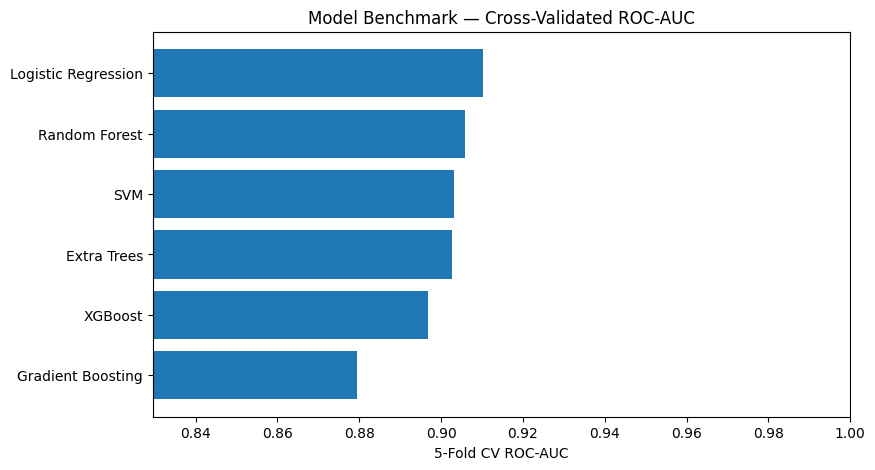

In [13]:
# Benchmark visualization
plot_df = benchmark_results.sort_values("ROC-AUC mean")
plt.figure(figsize=(9, 5))
plt.barh(plot_df["Model"], plot_df["ROC-AUC mean"])
plt.xlabel("5-Fold CV ROC-AUC")
plt.title("Model Benchmark — Cross-Validated ROC-AUC")
plt.xlim(max(0.45, plot_df["ROC-AUC mean"].min() - 0.05), 1.0)
plt.show()


## 9. Hyperparameter Optimization

We now tune the strongest tree-based candidates.

The search uses **RandomizedSearchCV with stratified 5-fold CV**. This is preferable to repeatedly testing many combinations on the holdout set.

The holdout set remains untouched.


In [14]:
# XGBoost randomized search
xgb_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist"
    ))
])

xgb_param_distributions = {
    "model__n_estimators": [100, 200, 300, 500, 700],
    "model__max_depth": [2, 3, 4, 5],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5, 8],
    "model__gamma": [0, 0.05, 0.1, 0.2],
    "model__reg_alpha": [0, 0.01, 0.1, 0.5, 1.0],
    "model__reg_lambda": [1, 2, 5, 10],
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipe,
    param_distributions=xgb_param_distributions,
    n_iter=40,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

xgb_search.fit(X_train, y_train)

print("Best CV ROC-AUC:", round(xgb_search.best_score_, 5))
print("Best parameters:")
display(pd.Series(xgb_search.best_params_))


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV ROC-AUC: 0.90818
Best parameters:


,0
model__subsample,1.00
model__reg_lambda,1.00
model__reg_alpha,1.00
model__n_estimators,100.00
model__min_child_weight,8.00
model__max_depth,5.00
model__learning_rate,0.05
model__gamma,0.00
model__colsample_bytree,0.80


In [15]:
# Extra Trees randomized search
et_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", ExtraTreesClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

et_param_distributions = {
    "model__n_estimators": [300, 500, 800, 1200],
    "model__max_depth": [None, 4, 6, 8, 12],
    "model__min_samples_split": [2, 4, 6, 10],
    "model__min_samples_leaf": [1, 2, 4, 6],
    "model__max_features": ["sqrt", "log2", 0.5, 0.8],
}

et_search = RandomizedSearchCV(
    estimator=et_pipe,
    param_distributions=et_param_distributions,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)

et_search.fit(X_train, y_train)

print("Best Extra Trees CV ROC-AUC:", round(et_search.best_score_, 5))
print("Best parameters:")
display(pd.Series(et_search.best_params_))


Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Extra Trees CV ROC-AUC: 0.91746
Best parameters:


,0
model__n_estimators,800
model__min_samples_split,4
model__min_samples_leaf,6
model__max_features,log2
model__max_depth,6


## 10. Select the Candidate Model

Selection is based on cross-validation evidence, not on the holdout score.

We compare the tuned XGBoost and Extra Trees models with the benchmark leader and choose the candidate with the strongest validation profile.

For a medical-risk portfolio, a slightly lower ROC-AUC model may still be preferable if its recall, calibration, or threshold behavior is materially better. Therefore the final choice should be justified with the complete metric table.


In [16]:
candidate_models = {
    "Tuned XGBoost": xgb_search.best_estimator_,
    "Tuned Extra Trees": et_search.best_estimator_,
}

# Add benchmark leader as another candidate
benchmark_leader_name = benchmark_results.iloc[0]["Model"]
candidate_models[f"Benchmark Leader: {benchmark_leader_name}"] = benchmark_pipelines[benchmark_leader_name]

candidate_rows = []
for name, model in candidate_models.items():
    scores = cross_validate(
        model, X_train, y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )
    candidate_rows.append({
        "Model": name,
        "ROC-AUC": scores["test_roc_auc"].mean(),
        "PR-AUC": scores["test_pr_auc"].mean(),
        "Recall": scores["test_recall"].mean(),
        "Precision": scores["test_precision"].mean(),
        "F1": scores["test_f1"].mean(),
    })

candidate_results = pd.DataFrame(candidate_rows).sort_values(
    ["ROC-AUC", "PR-AUC"], ascending=False
).reset_index(drop=True)

display(candidate_results.style.format({
    c: "{:.4f}" for c in candidate_results.columns if c != "Model"
}))

FINAL_MODEL_NAME = candidate_results.iloc[0]["Model"]
final_base_model = candidate_models[FINAL_MODEL_NAME]

print("Selected candidate:", FINAL_MODEL_NAME)


,Model,ROC-AUC,PR-AUC,Recall,Precision,F1
0,Tuned Extra Trees,0.9175,0.9196,0.8016,0.8098,0.8006
1,Benchmark Leader: Logistic Regression,0.9102,0.9122,0.8437,0.8033,0.8192
2,Tuned XGBoost,0.9082,0.9129,0.8121,0.8099,0.8071


Selected candidate: Tuned Extra Trees


## 11. Probability Calibration

A classifier can rank patients well while producing poorly calibrated probabilities.

We therefore create a calibrated version of the selected candidate using `CalibratedClassifierCV`.

**Important:** calibration is evaluated on cross-validated predictions from the training partition before the untouched holdout is used.


In [17]:
calibrated_model = CalibratedClassifierCV(
    estimator=clone(final_base_model),
    method="sigmoid",
    cv=5
)

calibrated_model.fit(X_train, y_train)

test_prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

print("Holdout ROC-AUC:", round(roc_auc_score(y_test, test_prob_calibrated), 4))
print("Holdout PR-AUC:", round(average_precision_score(y_test, test_prob_calibrated), 4))
print("Holdout Brier score:", round(brier_score_loss(y_test, test_prob_calibrated), 4))


Holdout ROC-AUC: 0.8972
Holdout PR-AUC: 0.852
Holdout Brier score: 0.126


## 12. Decision Threshold Optimization

The default classification threshold of `0.50` is not automatically optimal.

For a screening-oriented educational experiment, we inspect a range of thresholds and report the precision/recall/F1 trade-off.

**Crucial:** threshold selection is performed from out-of-fold predictions on the training partition, not from the holdout labels.


In [18]:
# Generate out-of-fold probabilities on training data
oof_prob = cross_val_predict(
    calibrated_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_rows = []
for threshold in np.linspace(0.10, 0.90, 161):
    pred = (oof_prob >= threshold).astype(int)
    threshold_rows.append({
        "threshold": threshold,
        "precision": precision_score(y_train, pred, zero_division=0),
        "recall": recall_score(y_train, pred, zero_division=0),
        "f1": f1_score(y_train, pred, zero_division=0),
        "specificity": recall_score(y_train, pred, pos_label=0, zero_division=0),
    })

threshold_df = pd.DataFrame(threshold_rows)

# Portfolio default: maximize F1 while maintaining at least 0.80 recall if possible.
eligible = threshold_df[threshold_df["recall"] >= 0.80]
if len(eligible) > 0:
    best_threshold_row = eligible.sort_values("f1", ascending=False).iloc[0]
else:
    best_threshold_row = threshold_df.sort_values("f1", ascending=False).iloc[0]

OPTIMAL_THRESHOLD = float(best_threshold_row["threshold"])

print("Selected threshold:", round(OPTIMAL_THRESHOLD, 3))
display(best_threshold_row.to_frame("value"))


Selected threshold: 0.455


,value
threshold,0.455000
precision,0.784314
recall,0.833333
f1,0.808081
specificity,0.816667


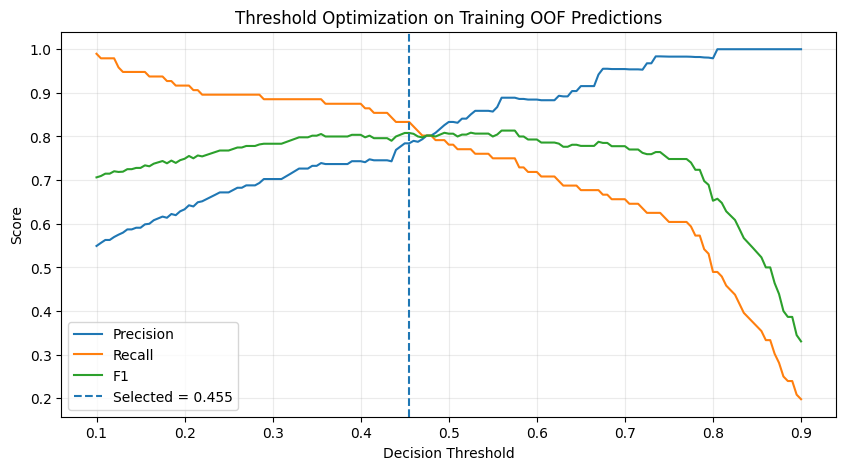

In [19]:
# Threshold trade-off plot
plt.figure(figsize=(10, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], label="F1")
plt.axvline(OPTIMAL_THRESHOLD, linestyle="--", label=f"Selected = {OPTIMAL_THRESHOLD:.3f}")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization on Training OOF Predictions")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 13. Final Holdout Evaluation

The holdout set has now remained untouched through:

- preprocessing design
- model benchmarking
- hyperparameter tuning
- candidate selection
- threshold selection

We can therefore use it once for an honest final estimate.


In [20]:
# Evaluate calibrated model at both default and optimized thresholds
default_pred = (test_prob_calibrated >= 0.50).astype(int)
optimized_pred = (test_prob_calibrated >= OPTIMAL_THRESHOLD).astype(int)

def evaluate_predictions(y_true, prob, pred, label):
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Evaluation": label,
        "ROC-AUC": roc_auc_score(y_true, prob),
        "PR-AUC": average_precision_score(y_true, prob),
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall/Sensitivity": recall_score(y_true, pred, zero_division=0),
        "Specificity": specificity,
        "F1": f1_score(y_true, pred, zero_division=0),
        "Brier": brier_score_loss(y_true, prob),
    }

final_metrics = pd.DataFrame([
    evaluate_predictions(y_test, test_prob_calibrated, default_pred, "Threshold 0.50"),
    evaluate_predictions(y_test, test_prob_calibrated, optimized_pred, f"Optimized threshold {OPTIMAL_THRESHOLD:.3f}"),
])

display(final_metrics.style.format({
    c: "{:.4f}" for c in final_metrics.columns if c != "Evaluation"
}))

print("\nClassification report — optimized threshold")
print(classification_report(y_test, optimized_pred, digits=4))


,Evaluation,ROC-AUC,PR-AUC,Accuracy,Precision,Recall/Sensitivity,Specificity,F1,Brier
0,Threshold 0.50,0.8972,0.8520,0.8519,0.7857,0.9167,0.8000,0.8462,0.1260
1,Optimized threshold 0.455,0.8972,0.8520,0.8333,0.7586,0.9167,0.7667,0.8302,0.1260



Classification report — optimized threshold
              precision    recall  f1-score   support

           0     0.9200    0.7667    0.8364        30
           1     0.7586    0.9167    0.8302        24

    accuracy                         0.8333        54
   macro avg     0.8393    0.8417    0.8333        54
weighted avg     0.8483    0.8333    0.8336        54



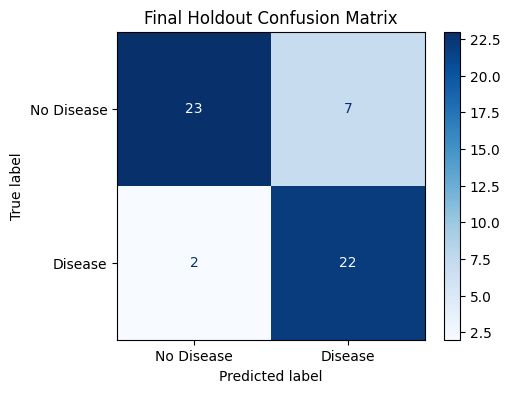

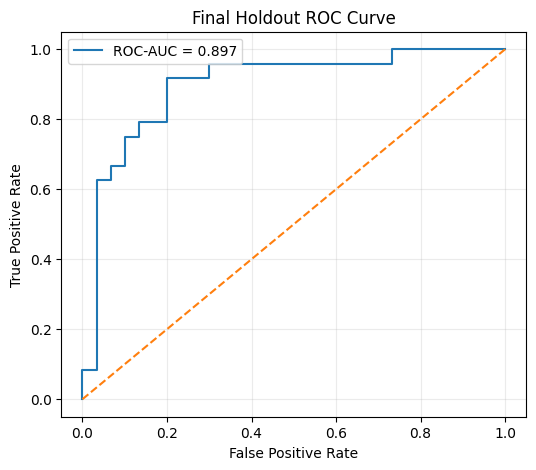

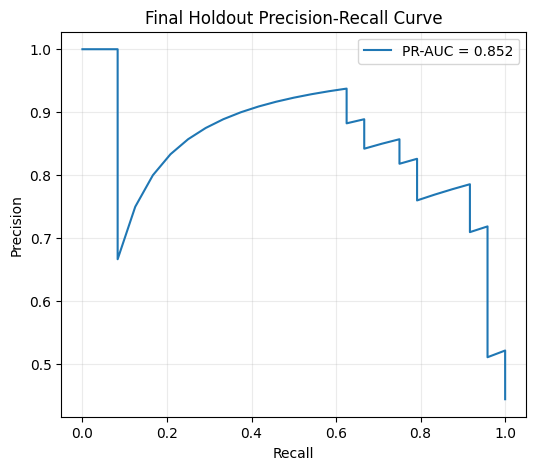

In [21]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, optimized_pred,
    display_labels=["No Disease", "Disease"],
    cmap="Blues",
    ax=ax
)
ax.set_title("Final Holdout Confusion Matrix")
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, test_prob_calibrated)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, test_prob_calibrated):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final Holdout ROC Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

# Precision-recall curve
precision, recall, _ = precision_recall_curve(y_test, test_prob_calibrated)
plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, test_prob_calibrated):.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Final Holdout Precision-Recall Curve")
plt.legend()
plt.grid(alpha=0.25)
plt.show()


## 14. Calibration Analysis

A probability such as `0.80` should ideally correspond to approximately 80% positive outcomes among comparable predictions.

We inspect a reliability diagram and Brier score. Calibration quality should be discussed separately from discrimination.


<Figure size 700x600 with 0 Axes>

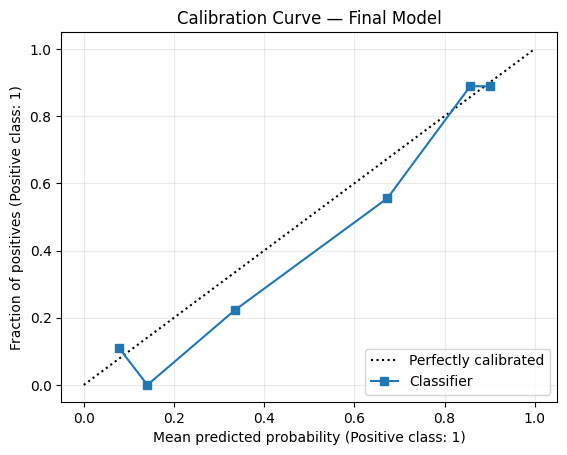

In [22]:
plt.figure(figsize=(7, 6))
CalibrationDisplay.from_predictions(
    y_test,
    test_prob_calibrated,
    n_bins=6,
    strategy="quantile",
)
plt.title("Calibration Curve — Final Model")
plt.grid(alpha=0.25)
plt.show()


## 15. Error Analysis

We inspect the holdout cases where the model made classification errors at the selected threshold.

Questions to ask:

- Are false negatives concentrated in particular clinical profiles?
- Are false positives associated with borderline probabilities?
- Are errors associated with specific age ranges or symptom categories?
- Are there suspiciously influential variables?

Because the holdout is small, these observations are exploratory rather than statistically conclusive.


In [23]:
error_analysis = X_test.copy()
error_analysis["actual"] = y_test.values
error_analysis["probability"] = test_prob_calibrated
error_analysis["prediction"] = optimized_pred
error_analysis["error_type"] = np.select(
    [
        (error_analysis["actual"] == 1) & (error_analysis["prediction"] == 0),
        (error_analysis["actual"] == 0) & (error_analysis["prediction"] == 1),
    ],
    ["False Negative", "False Positive"],
    default="Correct"
)

errors = error_analysis[error_analysis["error_type"] != "Correct"].copy()
print("Total holdout errors:", len(errors))
display(errors.sort_values("probability").head(20))


Total holdout errors: 9


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,actual,probability,prediction,error_type
67,58,Female,2,136,319,1,2,152,0,0.0,1,2,3,1,0.103095,0,False Negative
101,67,Male,4,120,237,0,0,71,0,1.0,2,0,3,1,0.340904,0,False Negative
268,57,Male,4,140,192,0,0,148,0,0.4,2,0,6,0,0.485902,1,False Positive
158,56,Male,1,120,193,0,2,162,0,1.9,2,0,7,0,0.576715,1,False Positive
217,51,Male,3,94,227,0,0,154,1,0.0,1,1,7,0,0.591695,1,False Positive
187,52,Male,4,108,233,1,0,147,0,0.1,1,3,7,0,0.746829,1,False Positive
84,57,Male,4,110,201,0,0,126,1,1.5,2,0,6,0,0.811640,1,False Positive
234,62,Male,3,130,231,0,0,146,0,1.8,2,3,7,0,0.846757,1,False Positive
3,64,Male,4,128,263,0,0,105,1,0.2,2,1,7,0,0.926666,1,False Positive


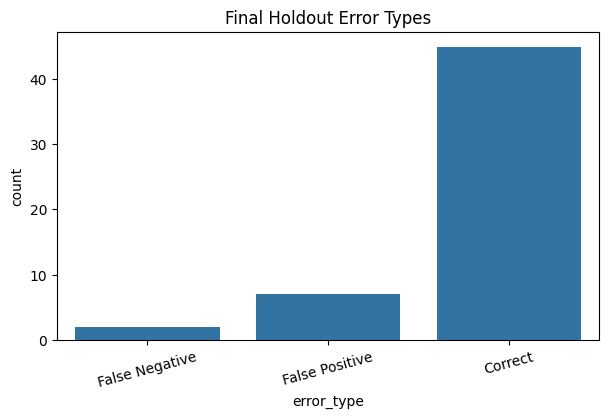

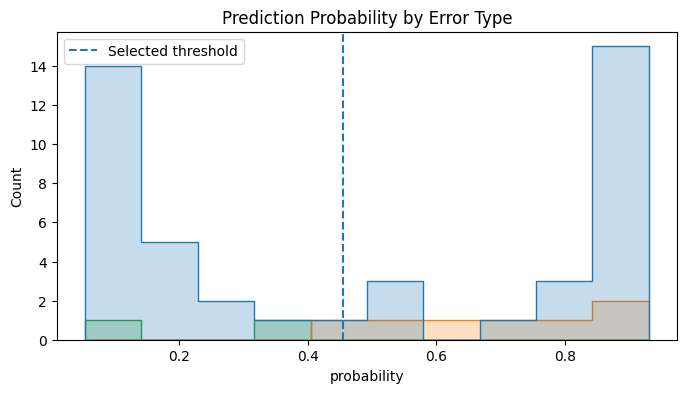

In [24]:
# Error-type counts
plt.figure(figsize=(7, 4))
sns.countplot(data=error_analysis, x="error_type", order=["False Negative", "False Positive", "Correct"])
plt.title("Final Holdout Error Types")
plt.xticks(rotation=15)
plt.show()

# Error probability distribution
plt.figure(figsize=(8, 4))
sns.histplot(
    data=error_analysis,
    x="probability",
    hue="error_type",
    bins=10,
    element="step",
    stat="count",
    common_norm=False
)
plt.axvline(OPTIMAL_THRESHOLD, linestyle="--", label="Selected threshold")
plt.title("Prediction Probability by Error Type")
plt.legend()
plt.show()


## 16. Explainability — Permutation Importance

Permutation importance is computed on the untouched holdout set only after final model selection.

It measures how much performance decreases when a feature's values are randomly permuted.

This is model-agnostic and works with the complete preprocessing pipeline.


,feature,importance_mean,importance_std
12,Thallium,0.060046,0.027837
11,Number of vessels fluro,0.054398,0.017307
2,Chest pain type,0.031065,0.023648
8,Exercise angina,0.016343,0.014793
6,EKG results,0.008241,0.003911
10,Slope of ST,0.005463,0.020321
4,Cholesterol,0.001204,0.001175
7,Max HR,0.000231,0.002213
9,ST depression,-0.000185,0.003635
5,FBS over 120,-0.000278,0.000907


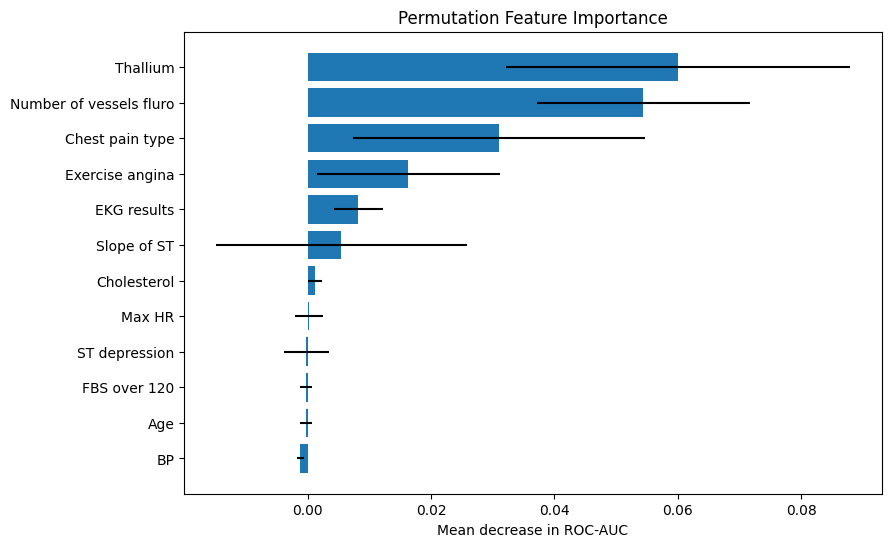

In [25]:
perm = permutation_importance(
    calibrated_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df)

plt.figure(figsize=(9, 6))
top_perm = perm_df.head(12).sort_values("importance_mean")
plt.barh(top_perm["feature"], top_perm["importance_mean"], xerr=top_perm["importance_std"])
plt.xlabel("Mean decrease in ROC-AUC")
plt.title("Permutation Feature Importance")
plt.show()


## 17. Optional SHAP Explainability

SHAP can provide richer local/global explanations for tree-based models. Because the final pipeline may be a calibrated wrapper and may not expose a simple tree estimator, this section is intentionally optional.

If the selected model is XGBoost, the underlying fitted XGBoost estimator can be extracted from the pipeline. Otherwise, permutation importance remains the primary model-agnostic explanation.

**Do not interpret feature importance as causal medical evidence.**


In [26]:
# Optional SHAP section
try:
    import shap
    print("SHAP version:", shap.__version__)

    # Attempt to locate a fitted XGBoost pipeline inside the calibrated model.
    base = calibrated_model.calibrated_classifiers_[0].estimator

    if isinstance(base, Pipeline) and "model" in base.named_steps:
        fitted_model = base.named_steps["model"]
        fitted_preprocessor = base.named_steps["preprocessor"]

        if isinstance(fitted_model, XGBClassifier):
            X_test_transformed = fitted_preprocessor.transform(X_test)
            feature_names = fitted_preprocessor.get_feature_names_out()

            explainer = shap.TreeExplainer(fitted_model)
            shap_values = explainer.shap_values(X_test_transformed)

            shap.summary_plot(
                shap_values,
                X_test_transformed,
                feature_names=feature_names,
                max_display=15,
                show=True
            )
        else:
            print("Final selected model is not XGBoost; use permutation importance above.")
    else:
        print("Could not extract a compatible tree estimator. Use permutation importance above.")

except Exception as e:
    print("SHAP section skipped:", repr(e))


SHAP version: 0.52.0
Final selected model is not XGBoost; use permutation importance above.


## 18. Model Stability Check

A single 5-fold CV estimate can still be noisy on a dataset with only 270 observations.

We therefore run **Repeated Stratified K-Fold CV** on the training partition for the selected base model.

This does not replace the final holdout evaluation; it gives a better sense of validation variability.


In [27]:
repeated_cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=RANDOM_STATE
)

stability_scores = cross_validate(
    final_base_model,
    X_train,
    y_train,
    cv=repeated_cv,
    scoring={"roc_auc": "roc_auc", "pr_auc": "average_precision", "f1": "f1", "recall": "recall"},
    n_jobs=-1
)

stability_summary = pd.DataFrame({
    "Metric": ["ROC-AUC", "PR-AUC", "F1", "Recall"],
    "Mean": [
        stability_scores["test_roc_auc"].mean(),
        stability_scores["test_pr_auc"].mean(),
        stability_scores["test_f1"].mean(),
        stability_scores["test_recall"].mean(),
    ],
    "Std": [
        stability_scores["test_roc_auc"].std(),
        stability_scores["test_pr_auc"].std(),
        stability_scores["test_f1"].std(),
        stability_scores["test_recall"].std(),
    ],
})
display(stability_summary.style.format({"Mean": "{:.4f}", "Std": "{:.4f}"}))


,Metric,Mean,Std
0,ROC-AUC,0.9156,0.0555
1,PR-AUC,0.9206,0.0501
2,F1,0.8071,0.0777
3,Recall,0.8081,0.1092


## 19. Final Model Training and Serialization

For deployment-style inference, we fit the calibrated model on the complete development partition (`X_train`, `y_train`) and save:

- the fitted model
- the selected threshold
- feature metadata
- project configuration

The untouched holdout is still retained only for the reported final evaluation.


In [28]:
# Fit final calibrated model on the complete development set
final_model = CalibratedClassifierCV(
    estimator=clone(final_base_model),
    method="sigmoid",
    cv=5
)
final_model.fit(X_train, y_train)

ARTIFACT = {
    "model": final_model,
    "threshold": OPTIMAL_THRESHOLD,
    "target": TARGET,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "dropped_columns": ID_COLUMNS,
    "random_state": RANDOM_STATE,
    "model_name": FINAL_MODEL_NAME,
}

MODEL_PATH = "/content/heart_disease_model.joblib"
joblib.dump(ARTIFACT, MODEL_PATH)

print("Saved:", MODEL_PATH)


Saved: /content/heart_disease_model.joblib


## 20. Reusable Prediction Function

The function below accepts a DataFrame with the original modeling features and returns:

- predicted probability
- predicted class using the portfolio threshold

It deliberately requires the expected columns so silent feature-order mistakes are less likely.


In [29]:
def predict_heart_disease(new_data, artifact=ARTIFACT):
    """Generate heart-disease probabilities and thresholded predictions."""
    required = artifact["numeric_features"] + artifact["categorical_features"]
    missing = [c for c in required if c not in new_data.columns]

    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    model = artifact["model"]
    threshold = artifact["threshold"]

    X_new = new_data[required].copy()
    probability = model.predict_proba(X_new)[:, 1]
    prediction = (probability >= threshold).astype(int)

    result = X_new.copy()
    result["heart_disease_probability"] = probability
    result["heart_disease_prediction"] = prediction

    return result

# Example: inference on a few holdout rows
demo_predictions = predict_heart_disease(X_test.head(5))
display(demo_predictions)


,Age,BP,Cholesterol,Max HR,ST depression,Sex,Chest pain type,FBS over 120,EKG results,Exercise angina,Slope of ST,Number of vessels fluro,Thallium,heart_disease_probability,heart_disease_prediction
195,55,135,250,161,1.4,Female,2,0,2,0,2,0,3,0.093521,0
132,42,140,226,178,0.0,Male,4,0,0,0,1,0,3,0.139341,0
162,55,130,262,155,0.0,Male,2,0,0,0,1,0,3,0.080721,0
129,60,117,230,160,1.4,Male,4,1,0,1,1,2,7,0.865383,1
66,51,140,261,186,0.0,Male,4,0,2,1,1,0,3,0.411917,0


## 21. Basic Reproducibility / Integrity Checks

These checks make the portfolio project more production-minded:

- target must be binary
- expected columns must exist
- no identifier is passed into the model
- prediction probabilities must lie in `[0, 1]`
- saved artifact must reload successfully


In [30]:
# Integrity checks
assert set(y.unique()).issubset({0, 1})
assert TARGET not in X.columns
assert all(col not in X.columns for col in ID_COLUMNS)

reloaded_artifact = joblib.load(MODEL_PATH)
assert 0 <= reloaded_artifact["threshold"] <= 1

sample_prob = reloaded_artifact["model"].predict_proba(X_test.head(3))[:, 1]
assert np.all((sample_prob >= 0) & (sample_prob <= 1))

print("All reproducibility/integrity checks passed.")


All reproducibility/integrity checks passed.


## 22. Portfolio Results Summary

Run the final summary cell after all experiments.

When publishing the project, report the **actual values generated by this notebook**. Do not manually insert a target accuracy or AUC.

### Recommended README structure

1. Project overview
2. Dataset description
3. Business/clinical motivation
4. Data quality decisions
5. Leakage prevention
6. EDA
7. Modeling strategy
8. Cross-validation results
9. Hyperparameter optimization
10. Final holdout metrics
11. Threshold optimization
12. Calibration
13. Explainability
14. Error analysis
15. Limitations and ethics
16. Reproducibility
17. Installation / usage


In [31]:
# Final portfolio summary
print("=" * 70)
print("HEART DISEASE PREDICTION — FINAL PORTFOLIO SUMMARY")
print("=" * 70)

print(f"Dataset rows: {len(df)}")
print(f"Features used: {X.shape[1]}")
print(f"Selected model: {FINAL_MODEL_NAME}")
print(f"OOF-selected threshold: {OPTIMAL_THRESHOLD:.4f}")
print()

print("Final holdout metrics:")
display(final_metrics)

print("\nModel artifacts:")
print(MODEL_PATH)


HEART DISEASE PREDICTION — FINAL PORTFOLIO SUMMARY
Dataset rows: 270
Features used: 13
Selected model: Tuned Extra Trees
OOF-selected threshold: 0.4550

Final holdout metrics:


,Evaluation,ROC-AUC,PR-AUC,Accuracy,Precision,Recall/Sensitivity,Specificity,F1,Brier
0,Threshold 0.50,0.897222,0.851997,0.851852,0.785714,0.916667,0.800000,0.846154,0.125998
1,Optimized threshold 0.455,0.897222,0.851997,0.833333,0.758621,0.916667,0.766667,0.830189,0.125998



Model artifacts:
/content/heart_disease_model.joblib


## 23. Limitations, Ethics, and Responsible Use

This dataset is small, and the final holdout contains relatively few observations. Consequently:

- performance estimates have substantial uncertainty;
- cross-validation variability must be considered;
- the dataset may not represent the population in which a model would eventually be used;
- coded clinical variables may contain dataset-specific conventions;
- feature importance does not establish causality;
- probability calibration may not transfer to another population;
- threshold selection reflects the chosen portfolio objective, not a clinical guideline;
- this model must **not** be used to diagnose or rule out heart disease.

A real clinical system would require external validation, prospective evaluation, clinical governance, fairness analysis, monitoring, data-quality controls, privacy/security safeguards, and regulatory review.


## 24. Professional Portfolio Checklist

### Data
- [x] Dataset audit
- [x] Missing-value analysis
- [x] Duplicate check
- [x] Identifier/leakage review
- [x] Feature-type decisions

### Modeling
- [x] Stratified train/holdout split
- [x] Leakage-safe preprocessing pipeline
- [x] Classical baseline
- [x] Multiple model families
- [x] Cross-validation
- [x] Hyperparameter optimization
- [x] Candidate model selection
- [x] Probability calibration
- [x] Threshold optimization

### Evaluation
- [x] ROC-AUC
- [x] PR-AUC
- [x] Accuracy
- [x] Precision
- [x] Recall/sensitivity
- [x] Specificity
- [x] F1
- [x] Brier score
- [x] Confusion matrix
- [x] ROC curve
- [x] Precision-recall curve
- [x] Calibration curve
- [x] Error analysis

### Explainability & engineering
- [x] Permutation importance
- [x] Optional SHAP
- [x] Repeated CV stability analysis
- [x] Serialized model artifact
- [x] Reusable prediction function
- [x] Integrity checks
- [x] Responsible-use discussion

### Recommended next portfolio additions
- external validation on an independent heart-disease dataset
- statistical confidence intervals / bootstrap uncertainty
- fairness analysis across relevant demographic groups
- FastAPI or Streamlit inference layer
- unit tests for preprocessing and inference
- CI/CD and versioned model artifacts
- Dockerized deployment
